STEP 2: DATA EXPLORATION

Dataset shape: (891, 12)
  → 891 passengers, 12 columns

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0   

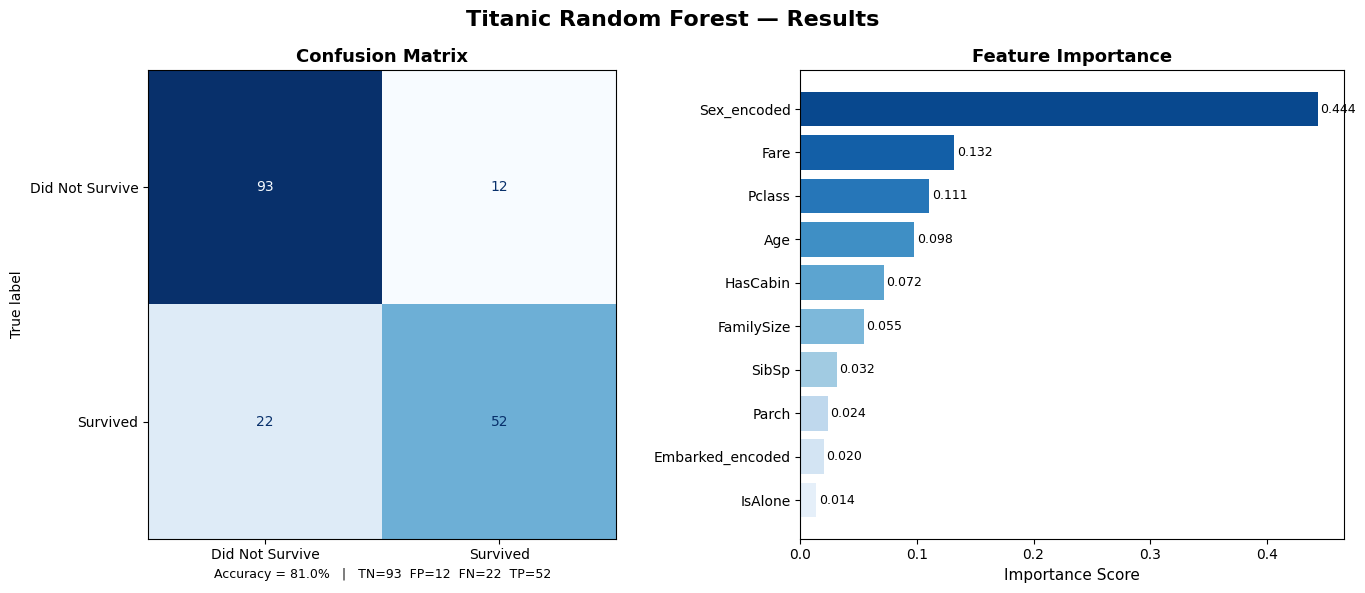

Charts saved to 'titanic_results.png'

SUMMARY
  Model        : Random Forest (100 trees, max_depth=5)
  Training rows: 712   |   Test rows: 179
  Accuracy     : 81.01%
  Top feature  : Sex_encoded (importance = 0.444)

Done! ✓


In [5]:
# =============================================================================
# TITANIC SURVIVAL PREDICTION — COMPLETE ML PROJECT FOR BEGINNERS
# =============================================================================
# Goal: Predict whether a passenger survived the Titanic disaster (1 = survived,
#       0 = did not survive) using a Random Forest classifier.
# =============================================================================


# -----------------------------------------------------------------------------
# STEP 1 — IMPORT LIBRARIES
# -----------------------------------------------------------------------------

import pandas as pd          # pandas: loads and manipulates tabular data (like Excel in Python)
import numpy as np           # numpy: fast math on arrays/numbers
import matplotlib.pyplot as plt  # matplotlib: draws charts and graphs
import seaborn as sns        # seaborn: prettier statistical charts built on matplotlib

from sklearn.ensemble import RandomForestClassifier  # the ML model we'll use
from sklearn.model_selection import train_test_split  # splits data into train/test sets
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
# accuracy_score   → tells us what % of predictions were correct
# confusion_matrix → table showing correct vs wrong predictions broken down by class
# ConfusionMatrixDisplay → helper that draws the confusion matrix as a heatmap


# -----------------------------------------------------------------------------
# STEP 2 — LOAD AND EXPLORE THE DATA
# -----------------------------------------------------------------------------

df = pd.read_csv("train.csv")  # read the CSV file into a DataFrame (a table of rows & columns)

print("=" * 60)
print("STEP 2: DATA EXPLORATION")
print("=" * 60)

print(f"\nDataset shape: {df.shape}")        # shape = (rows, columns) — tells us how big the table is
print(f"  → {df.shape[0]} passengers, {df.shape[1]} columns\n")

print("First 5 rows:")
print(df.head())                             # head() shows the first 5 rows so we can see what the data looks like

print("\nColumn data types:")
print(df.dtypes)                             # dtypes tells us if each column is a number, text, etc.

print("\nMissing values per column:")
print(df.isnull().sum())                     # isnull() marks each cell True/False; sum() counts the Trues per column
# Result: Age has 177 missing, Cabin has 687 missing, Embarked has 2 missing

print("\nBasic statistics (numeric columns):")
print(df.describe())                         # describe() gives count, mean, min, max, etc. for numeric columns


# -----------------------------------------------------------------------------
# STEP 3 — CLEAN MISSING VALUES
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 3: CLEANING MISSING VALUES")
print("=" * 60)

# --- Age: 177 missing values ---
# Strategy: fill missing ages with the MEDIAN age (middle value of all ages).
# We use median rather than mean because a few very old passengers would skew the mean.
median_age = df["Age"].median()             # calculate the median age from all non-missing values
df["Age"] = df["Age"].fillna(median_age)    # replace every NaN in Age with that median value
print(f"\nFilled {177} missing Age values with median age: {median_age:.1f} years")

# --- Embarked: 2 missing values ---
# Strategy: fill with the MODE (most common port).
# Embarked = port of embarkation: S = Southampton, C = Cherbourg, Q = Queenstown
mode_embarked = df["Embarked"].mode()[0]    # mode() returns a Series; [0] gets the top value
df["Embarked"] = df["Embarked"].fillna(mode_embarked)  # fill both NaNs with that value
print(f"Filled 2 missing Embarked values with mode: '{mode_embarked}'")

# --- Cabin: 687 missing (77% of rows!) ---
# Strategy: instead of guessing, just flag whether the cabin was recorded or not.
# A recorded cabin may hint at a wealthier/higher-class passenger.
df["HasCabin"] = df["Cabin"].notna().astype(int)  # notna() → True if cabin known; astype(int) → 1/0
print("Created binary 'HasCabin' feature from Cabin column (1 = cabin known, 0 = unknown)")

# Verify no more missing values in the columns we care about
print(f"\nRemaining nulls in used columns: {df[['Age','Embarked','HasCabin']].isnull().sum().sum()}")


# -----------------------------------------------------------------------------
# STEP 4 — FEATURE ENGINEERING
# -----------------------------------------------------------------------------
# Feature engineering = creating new, more informative columns from existing ones.

print("\n" + "=" * 60)
print("STEP 4: FEATURE ENGINEERING")
print("=" * 60)

# --- FamilySize: total family members aboard ---
# SibSp = number of siblings + spouses aboard
# Parch  = number of parents + children aboard
# Adding 1 to include the passenger themselves
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
print("Created 'FamilySize' = SibSp + Parch + 1 (includes the passenger)")

# --- IsAlone: 1 if travelling solo, 0 if with family ---
# A solo traveller may have different survival odds than someone with family
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)  # True/False → 1/0
print("Created 'IsAlone' = 1 if FamilySize == 1, else 0")

# --- Sex_encoded: convert text 'male'/'female' to numbers ---
# Machine learning models only understand numbers, not text strings.
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)  # female=1, male=0
print("Encoded 'Sex': female=1, male=0  →  'Sex_encoded'")

# --- Embarked_encoded: convert port letter to a number ---
# Simple label encoding: S=0, C=1, Q=2  (arbitrary but works for a tree-based model)
embarked_map = {"S": 0, "C": 1, "Q": 2}                 # dictionary mapping letter → number
df["Embarked_encoded"] = df["Embarked"].map(embarked_map)  # apply that mapping to every row
print("Encoded 'Embarked': S=0, C=1, Q=2  →  'Embarked_encoded'")

# --- Select final feature columns ---
# We deliberately drop: PassengerId (arbitrary ID), Name, Ticket, Cabin (replaced by HasCabin),
# original Sex and Embarked text columns (already encoded above), and the target 'Survived'.
FEATURES = [
    "Pclass",           # ticket class (1 = 1st/richest, 3 = 3rd/cheapest)
    "Sex_encoded",      # gender encoded as 0/1
    "Age",              # age in years (cleaned)
    "SibSp",            # siblings/spouses aboard
    "Parch",            # parents/children aboard
    "Fare",             # ticket price paid
    "Embarked_encoded", # port encoded as 0/1/2
    "HasCabin",         # whether cabin was recorded
    "FamilySize",       # total family size
    "IsAlone",          # solo traveller flag
]

X = df[FEATURES]        # X = the input features the model will learn from (everything except survived)
y = df["Survived"]      # y = the label/target we want to predict (0 or 1)

print(f"\nFinal feature matrix X: {X.shape[0]} rows × {X.shape[1]} columns")
print(f"Target vector y: {y.shape[0]} values  ({y.sum()} survived, {(y==0).sum()} did not)")


# -----------------------------------------------------------------------------
# STEP 5 — TRAIN / TEST SPLIT
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 5: TRAIN/TEST SPLIT")
print("=" * 60)

# We split the data into two parts:
#   • Training set (80%): the model LEARNS from this data
#   • Test set    (20%): we EVALUATE the model on data it has NEVER seen
#
# random_state=42 makes the split reproducible — same split every time you run the script.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% goes to the test set
    random_state=42      # fix the random seed for reproducibility
)

print(f"Training set : {X_train.shape[0]} passengers")
print(f"Test set     : {X_test.shape[0]} passengers")


# -----------------------------------------------------------------------------
# STEP 6 — TRAIN THE RANDOM FOREST MODEL
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 6: TRAINING THE RANDOM FOREST")
print("=" * 60)

# Random Forest = an ensemble of many decision trees.
# Each tree is trained on a random subset of the data and features,
# then all trees VOTE on the final prediction — majority wins.
# This reduces overfitting compared to a single deep tree.
#
# n_estimators=100 → build 100 trees in the forest
# max_depth=5      → each tree can have at most 5 levels (prevents over-fitting)
# random_state=42  → reproducible results

model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    max_depth=5,        # maximum depth of each tree
    random_state=42     # fixed seed for reproducibility
)

model.fit(X_train, y_train)  # fit() = training phase: the model learns from (features, labels) pairs
print("Model trained successfully!")


# -----------------------------------------------------------------------------
# STEP 7 — EVALUATE THE MODEL
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 7: MODEL EVALUATION")
print("=" * 60)

# Generate predictions on the TEST set (data the model has never seen)
y_pred = model.predict(X_test)  # predict() returns an array of 0s and 1s

# --- Accuracy ---
# Accuracy = (number of correct predictions) / (total predictions)
accuracy = accuracy_score(y_test, y_pred)  # compare true labels vs predicted labels
print(f"\nAccuracy on test set: {accuracy:.4f}  ({accuracy*100:.2f}%)")
print("  → This means the model correctly predicted survival for that % of passengers.")

# --- Confusion Matrix ---
# A 2×2 table:
#                  Predicted: 0   Predicted: 1
#   Actual: 0   [[  TN            FP  ]]
#   Actual: 1   [[  FN            TP  ]]
#
# TN = True Negative  (correctly predicted 'did not survive')
# FP = False Positive (incorrectly predicted 'survived')
# FN = False Negative (incorrectly predicted 'did not survive')
# TP = True Positive  (correctly predicted 'survived')

cm = confusion_matrix(y_test, y_pred)  # compute the confusion matrix
print(f"\nConfusion Matrix:\n{cm}")
tn, fp, fn, tp = cm.ravel()           # ravel() flattens 2×2 → 4 values
print(f"  True Negatives  (correctly predicted NOT survived): {tn}")
print(f"  False Positives (incorrectly predicted survived)  : {fp}")
print(f"  False Negatives (incorrectly predicted NOT survived): {fn}")
print(f"  True Positives  (correctly predicted survived)    : {tp}")


# -----------------------------------------------------------------------------
# STEP 8 — VISUALISATIONS (Confusion Matrix + Feature Importance)
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 8: GENERATING CHARTS")
print("=" * 60)

# We'll build a side-by-side figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns of charts, figure size 14×6 inches
fig.suptitle("Titanic Random Forest — Results", fontsize=16, fontweight="bold")  # overall title


# ── Chart 1: Confusion Matrix Heatmap ──────────────────────────────────────
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,                        # the matrix we computed above
    display_labels=["Did Not Survive", "Survived"]  # human-readable axis labels
)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")  # draw on the left subplot, blue colour map
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")

# Add small text below the matrix explaining each quadrant
axes[0].set_xlabel(
    f"Accuracy = {accuracy*100:.1f}%   |   TN={tn}  FP={fp}  FN={fn}  TP={tp}",
    fontsize=9
)


# ── Chart 2: Feature Importance Bar Chart ──────────────────────────────────
# feature_importances_ = how much each feature contributed to the model's decisions.
# Higher = more important. Values sum to 1.0.
importances = model.feature_importances_               # numpy array of importance scores

# Pair each feature name with its importance score, then sort descending
importance_df = pd.DataFrame({
    "Feature":    FEATURES,        # list of column names
    "Importance": importances      # corresponding importance values
}).sort_values("Importance", ascending=False)  # sort so the most important feature is at the top

# Draw a horizontal bar chart
bars = axes[1].barh(
    importance_df["Feature"],      # y-axis: feature names
    importance_df["Importance"],   # x-axis: importance scores
    color=sns.color_palette("Blues_r", len(FEATURES))  # gradient blue palette, darkest = most important
)

# Add the importance value as a label at the end of each bar
for bar, val in zip(bars, importance_df["Importance"]):
    axes[1].text(
        bar.get_width() + 0.002,   # x position: just past the right edge of the bar
        bar.get_y() + bar.get_height() / 2,  # y position: vertically centred on the bar
        f"{val:.3f}",              # text: importance rounded to 3 decimal places
        va="center", fontsize=9    # vertically centred, small font
    )

axes[1].set_xlabel("Importance Score", fontsize=11)  # x-axis label
axes[1].set_title("Feature Importance", fontsize=13, fontweight="bold")  # chart title
axes[1].invert_yaxis()   # flip so most important feature appears at the TOP

plt.tight_layout()        # automatically adjust spacing so nothing overlaps
plt.savefig("titanic_results.png", dpi=150, bbox_inches="tight")  # save the figure to a PNG file
plt.show()                # display the figure on screen

print("Charts saved to 'titanic_results.png'")


# -----------------------------------------------------------------------------
# STEP 9 — SUMMARY
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Model        : Random Forest (100 trees, max_depth=5)")
print(f"  Training rows: {X_train.shape[0]}   |   Test rows: {X_test.shape[0]}")
print(f"  Accuracy     : {accuracy*100:.2f}%")
print(f"  Top feature  : {importance_df.iloc[0]['Feature']} "
      f"(importance = {importance_df.iloc[0]['Importance']:.3f})")
print("=" * 60)
print("\nDone! ✓")
